<a href="https://colab.research.google.com/github/AngelinaRoseVarghese/Machine_Learning/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

def evaluate(model_name, y_true, y_pred):
  print("\n","=" * 40)
  print(model_name)
  print("=" * 40)

  print("Accuracy:",accuracy_score(y_true, y_pred))
  print("Precision:",precision_score(y_true, y_pred))
  print("Recall:",recall_score(y_true, y_pred))
  print("F1 Score:",f1_score(y_true, y_pred))
  print("Confusion Matrix:\n",confusion_matrix(y_true, y_pred))

In [2]:
data = load_breast_cancer()

x = data.data
y = data.target

print("Dataset Shape: ",x.shape)
print("Classes: ",np.unique(y))


Dataset Shape:  (569, 30)
Classes:  [0 1]


In [3]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

In [4]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

mle_model = LogisticRegression(
    penalty = None,
    max_iter = 5000,
    random_state = 42
)

mle_model.fit(x_train, y_train)

y_pred_mle = mle_model.predict(x_test)

In [5]:
map_l2 = LogisticRegression(
    penalty = 'l2',
    C = 1.0,
    solver = 'lbfgs',

    max_iter = 5000,
    random_state = 42
)
map_l2.fit(x_train, y_train)
y_pred_l2 = map_l2.predict(x_test)

In [6]:
map_l1 = LogisticRegression(
    penalty = 'l1',
    solver = 'liblinear',
    C = 1.0,
    max_iter = 5000,
    random_state = 42
)
map_l1.fit(x_train, y_train)
y_pred_l1 = map_l1.predict(x_test)

evaluate("MLE", y_test, y_pred_mle)
evaluate("MAP (L2)", y_test, y_pred_l2)
evaluate("MAP (L1)", y_test, y_pred_l1)


MLE
Accuracy: 0.9210526315789473
Precision: 0.9701492537313433
Recall: 0.9027777777777778
F1 Score: 0.935251798561151
Confusion Matrix:
 [[40  2]
 [ 7 65]]

MAP (L2)
Accuracy: 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112
Confusion Matrix:
 [[41  1]
 [ 1 71]]

MAP (L1)
Accuracy: 0.9912280701754386
Precision: 0.9863013698630136
Recall: 1.0
F1 Score: 0.993103448275862
Confusion Matrix:
 [[41  1]
 [ 0 72]]


In [7]:
print("Number of zero coefficients ")
print("MLE: ", np.sum(mle_model.coef_[0] == 0))
print("MAP L2: ", np.sum(map_l2.coef_[0] == 0))
print("MAP L1: ", np.sum(map_l1.coef_[0] == 0))

Number of zero coefficients 
MLE:  0
MAP L2:  0
MAP L1:  14


In [8]:
results = pd.DataFrame(columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Reacall",
    "F1 Score"
])

models = [
    ("MLE", mle_model, y_pred_mle),
    ("MAP L2", map_l2, y_pred_l2),
    ("MAP L1", map_l1, y_pred_l1)
]

for name, model, pred in models:
  results.loc[len(results)] = [
      name,
      accuracy_score(y_test, pred),
      precision_score(y_test, pred),
      recall_score(y_test, pred),
      f1_score(y_test, pred)
  ]
print(results)

    Model  Accuracy  Precision   Reacall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


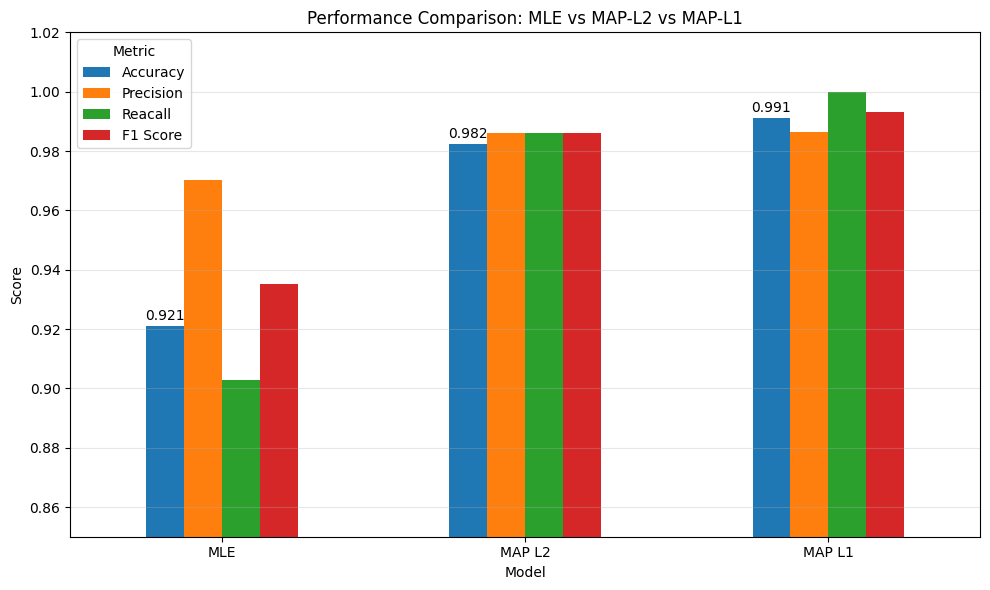

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [11]:
ax = results.set_index("Model").plot(
    kind = "bar",
    figsize = (10,6)
)
plt.title("Performance Comparison: MLE vs MAP-L2 vs MAP-L1")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.02)
plt.xticks(rotation = 0)
plt.legend(title = "Metric")
plt.grid(axis = "y", alpha = 0.3)

for container in ax.containers:
  ax.bar_label(container, fmt = "%.3f", padding = 2)

  plt.tight_layout()
  plt.show()

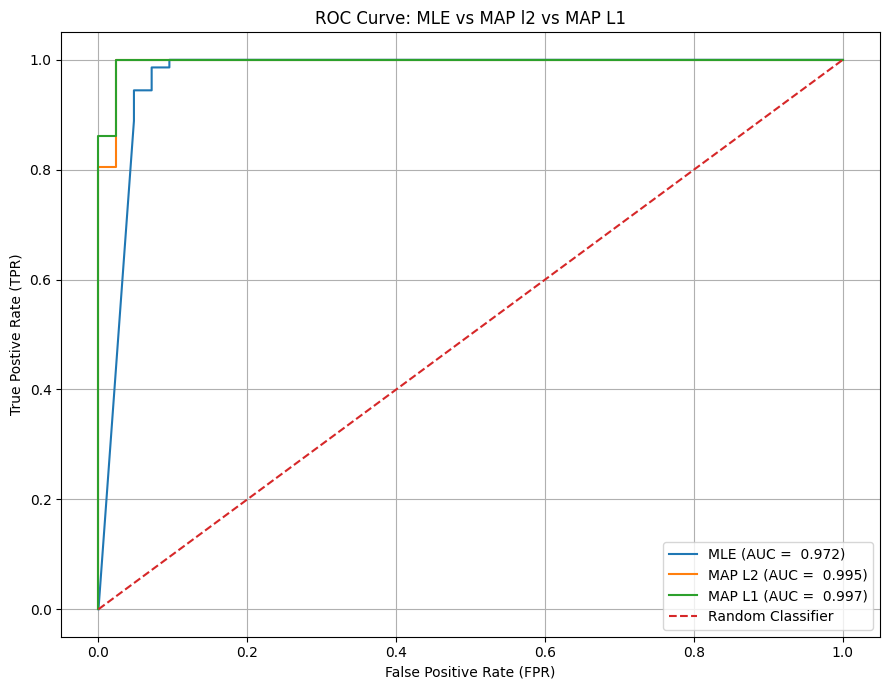

In [13]:
plt.figure(figsize = (9,7))
for name, model, pred in models:
  y_prob = model.predict_proba(x_test)[:,1]
  fpr,tpr,thresholds = roc_curve(y_test, y_prob)

  roc_auc = auc(fpr, tpr)

  plt.plot(
      fpr,
      tpr,
      label = f"{name} (AUC = {roc_auc: .3f})"
  )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle = "--",
    label = "Random Classifier"
  )

#Zoom into the useful region
# plt.xlim(0, 0.15)
# plt.ylim(0.75, 1.01)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Postive Rate (TPR)")
plt.title("ROC Curve: MLE vs MAP l2 vs MAP L1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()